<a href="https://colab.research.google.com/github/dakshini01/ProdFusion/blob/main/codes/Kalman_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# STEP 1: Import required libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# STEP 2: Upload dataset in Google Colab
# ============================================================

from google.colab import files
uploaded = files.upload()

# ============================================================
# STEP 3: Load the dataset
# ============================================================

df = pd.read_csv("garments_worker_productivity.csv")

# Display first few rows
df.head()

# ============================================================
# STEP 4: Convert date column into datetime format
# Kalman model needs time-ordered data
# ============================================================

df["date"] = pd.to_datetime(df["date"])

Saving garments_worker_productivity.csv to garments_worker_productivity (1).csv


In [3]:
# ============================================================
# STEP 4: Convert date column into datetime format
# Kalman model needs time-ordered data
# ============================================================

df["date"] = pd.to_datetime(df["date"])

# ============================================================
# STEP 5: Sort data by date
# This ensures productivity values are in correct time order
# ============================================================

df = df.sort_values("date")

# ============================================================
# STEP 6: Create daily average productivity
# Since there are multiple teams per day, we take average productivity per day
# ============================================================

daily = df.groupby("date")["actual_productivity"].mean().reset_index()

daily.head()



,date,actual_productivity
0,2015-01-01,0.718711
1,2015-01-03,0.802773
2,2015-01-04,0.780174
3,2015-01-05,0.796027
4,2015-01-06,0.805508


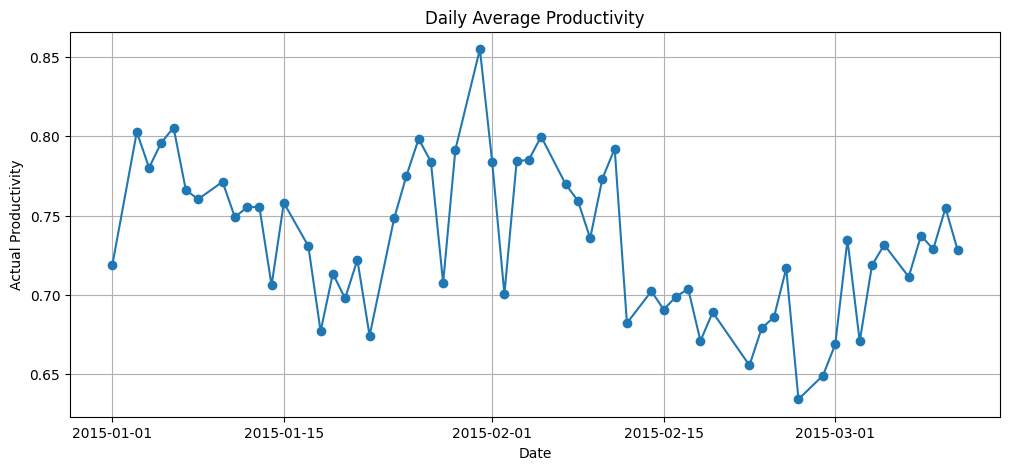

In [4]:
# ============================================================
# STEP 7: Plot original daily productivity
# This shows noisy daily productivity variation
# ============================================================

plt.figure(figsize=(12,5))
plt.plot(daily["date"], daily["actual_productivity"], marker="o")
plt.xlabel("Date")
plt.ylabel("Actual Productivity")
plt.title("Daily Average Productivity")
plt.grid(True)
plt.show()

In [5]:
# ============================================================
# STEP 8: Install Kalman filter package
# ============================================================

!pip install pykalman

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.1/252.1 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 9.9 MB/s eta 0:00:00


In [8]:
# ============================================================
# STEP 9: Import KalmanFilter
# ============================================================

from pykalman import KalmanFilter

# ============================================================
# STEP 10: Extract productivity values as time series
# This is the observed noisy signal
# ============================================================

y = daily["actual_productivity"].values

# ============================================================
# STEP 11: Define the Kalman Filter
#
# transition_matrices = [1]
#   means today's hidden productivity trend depends on yesterday's trend
#
# observation_matrices = [1]
#   means observed productivity is directly related to hidden trend
#
# observation_covariance
#   controls noise in actual observed productivity
#
# transition_covariance
#   controls how much the hidden productivity trend is allowed to change
# ============================================================

kf = KalmanFilter(
    transition_matrices=[1],
    observation_matrices=[1],
    initial_state_mean=y[0],
    initial_state_covariance=1,
    observation_covariance=0.01,
    transition_covariance=0.001
)

# ============================================================
# STEP 12: Apply Kalman filtering
# state_means gives the estimated hidden productivity trend
# ============================================================

state_means, state_covariances = kf.filter(y)

daily["kalman_smoothed"] = state_means.flatten()

daily.head()

,date,actual_productivity,kalman_smoothed
0,2015-01-01,0.718711,0.718711
1,2015-01-03,0.802773,0.762554
2,2015-01-04,0.780174,0.769308
3,2015-01-05,0.796027,0.778014
4,2015-01-06,0.805508,0.786225


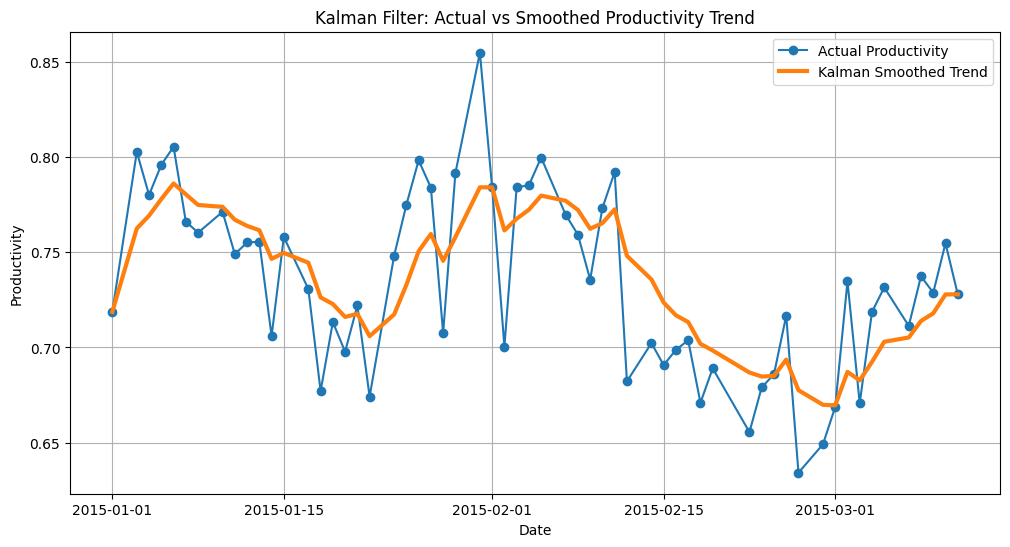

In [9]:
# ============================================================
# STEP 13: Plot actual productivity vs Kalman smoothed trend
# This is the main Kalman result for your project
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    daily["date"],
    daily["actual_productivity"],
    marker="o",
    label="Actual Productivity"
)

plt.plot(
    daily["date"],
    daily["kalman_smoothed"],
    linewidth=3,
    label="Kalman Smoothed Trend"
)

plt.xlabel("Date")
plt.ylabel("Productivity")
plt.title("Kalman Filter: Actual vs Smoothed Productivity Trend")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# ============================================================
# STEP 14: One-step-ahead forecast
# In this simple model, the next forecast is the latest estimated hidden state
# ============================================================

last_state = state_means[-1][0]
next_day_forecast = last_state

print("Next-day productivity forecast:", next_day_forecast)

Next-day productivity forecast: 0.7279172830582992


In [11]:
# ============================================================
# STEP 15: Calculate smoothing error
# This compares actual productivity with Kalman smoothed value
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_kalman = mean_absolute_error(
    daily["actual_productivity"],
    daily["kalman_smoothed"]
)

rmse_kalman = np.sqrt(
    mean_squared_error(
        daily["actual_productivity"],
        daily["kalman_smoothed"]
    )
)

print("Kalman MAE:", mae_kalman)
print("Kalman RMSE:", rmse_kalman)

Kalman MAE: 0.022200310377581845
Kalman RMSE: 0.027761711570456114
